In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from cuml.manifold import TSNE, UMAP
from cuml import PCA

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [5]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [7]:
SSR_synth_lst = []

for _ in range(7):
    SSR_synth_ds = DatasetFolderWithPath(
        os.path.join(data_workspace, "mat_files/synth"),
        extensions = (".mat"),
        transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.8, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
        loader = mat_file_loader
    )

    SSR_synth_ds_14_15_16 = filter_by_elev(SSR_synth_ds, {14, 15, 16})
    s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(SSR_synth_ds_14_15_16, bin_width=10)
    print_bin_summary(b, SSR_synth_ds_14_15_16)
    new_SSR_synth_ds_14_15_16 = AzimuthBinnedDataset(SSR_synth_ds_14_15_16, s, new_classes)

    SSR_synth_lst.append(new_SSR_synth_ds_14_15_16)

new_SSR_synth_ds_big_14_15_16 = ConcatDataset(SSR_synth_lst)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 14 – 79        7
2      btr70                11 – 79        7
3      m1                   10 – 79        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 79        7
8      t72                  13 – 79        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)
Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 14 – 79        7
2      btr70                11 – 79        7
3      m1                   10 – 79        7
4      m2                   10 – 79        7
5      m35      

In [8]:
meas_ds_14_15_16 = filter_by_elev(meas_ds, {14, 15, 16})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_14_15_16, bin_width=10)
print_bin_summary(b, meas_ds_14_15_16)

new_meas_ds_14_15_16 = AzimuthBinnedDataset(meas_ds_14_15_16, s, new_classes)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 14 – 79        7
2      btr70                11 – 79        7
3      m1                   10 – 79        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 79        7
8      t72                  13 – 79        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)


In [9]:
meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_17, bin_width=10)
print_bin_summary(b, meas_ds_17)

new_meas_ds_17 = AzimuthBinnedDataset(meas_ds_17, s, new_classes)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 12 – 79        7
2      btr70                11 – 79        7
3      m1                   12 – 78        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 77        7
8      t72                  11 – 78        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)


In [10]:
train_ds = new_SSR_synth_ds_big_14_15_16
valid_ds = new_meas_ds_14_15_16
test_ds  = new_meas_ds_17

ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

In [11]:
len(train_ds), len(valid_ds), len(test_ds)

(5642, 806, 539)

In [12]:
len(train_ds.datasets[0].classes), len(valid_ds.classes), len(test_ds.classes)

(70, 70, 70)

In [13]:
test_dataloader = DataLoader(
    test_ds, batch_size=32, shuffle=False, 
    num_workers=8, pin_memory = True, persistent_workers=True, 
    prefetch_factor=4
                            )

seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i} with seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(test_ds.classes))
    )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    n_test = len(test_ds)
    labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
    preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)

    idx = 0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            batch_size = labels.size(0)
            labels_tensor[idx:idx + batch_size] = labels
            preds_tensor[idx:idx + batch_size] = preds
            idx += batch_size

    correct = torch.sum(preds_tensor == labels_tensor).item()
    total = n_test
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc*100:.6f}")
    test_acc_lst.append(test_acc)

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.6f}")
print(f"Max: {test_acc_arr.max() * 100:.6f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.6f}, {test_acc_arr.std() * 100:.6f}")

Evaluating Run 0 with seed 10
Test Accuracy: 69.573284
Evaluating Run 1 with seed 42
Test Accuracy: 64.564007
Evaluating Run 2 with seed 100
Test Accuracy: 67.346939
Evaluating Run 3 with seed 123
Test Accuracy: 65.862709
Evaluating Run 4 with seed 666
Test Accuracy: 66.048237
Evaluating Run 5 with seed 777
Test Accuracy: 62.894249
Evaluating Run 6 with seed 849
Test Accuracy: 62.523191
Evaluating Run 7 with seed 1000
Test Accuracy: 64.935065
Evaluating Run 8 with seed 1111
Test Accuracy: 67.717996
Evaluating Run 9 with seed 1234
Test Accuracy: 69.387755
Min: 62.523191
Max: 69.573284
Avg, Std: 66.085343, 2.321409


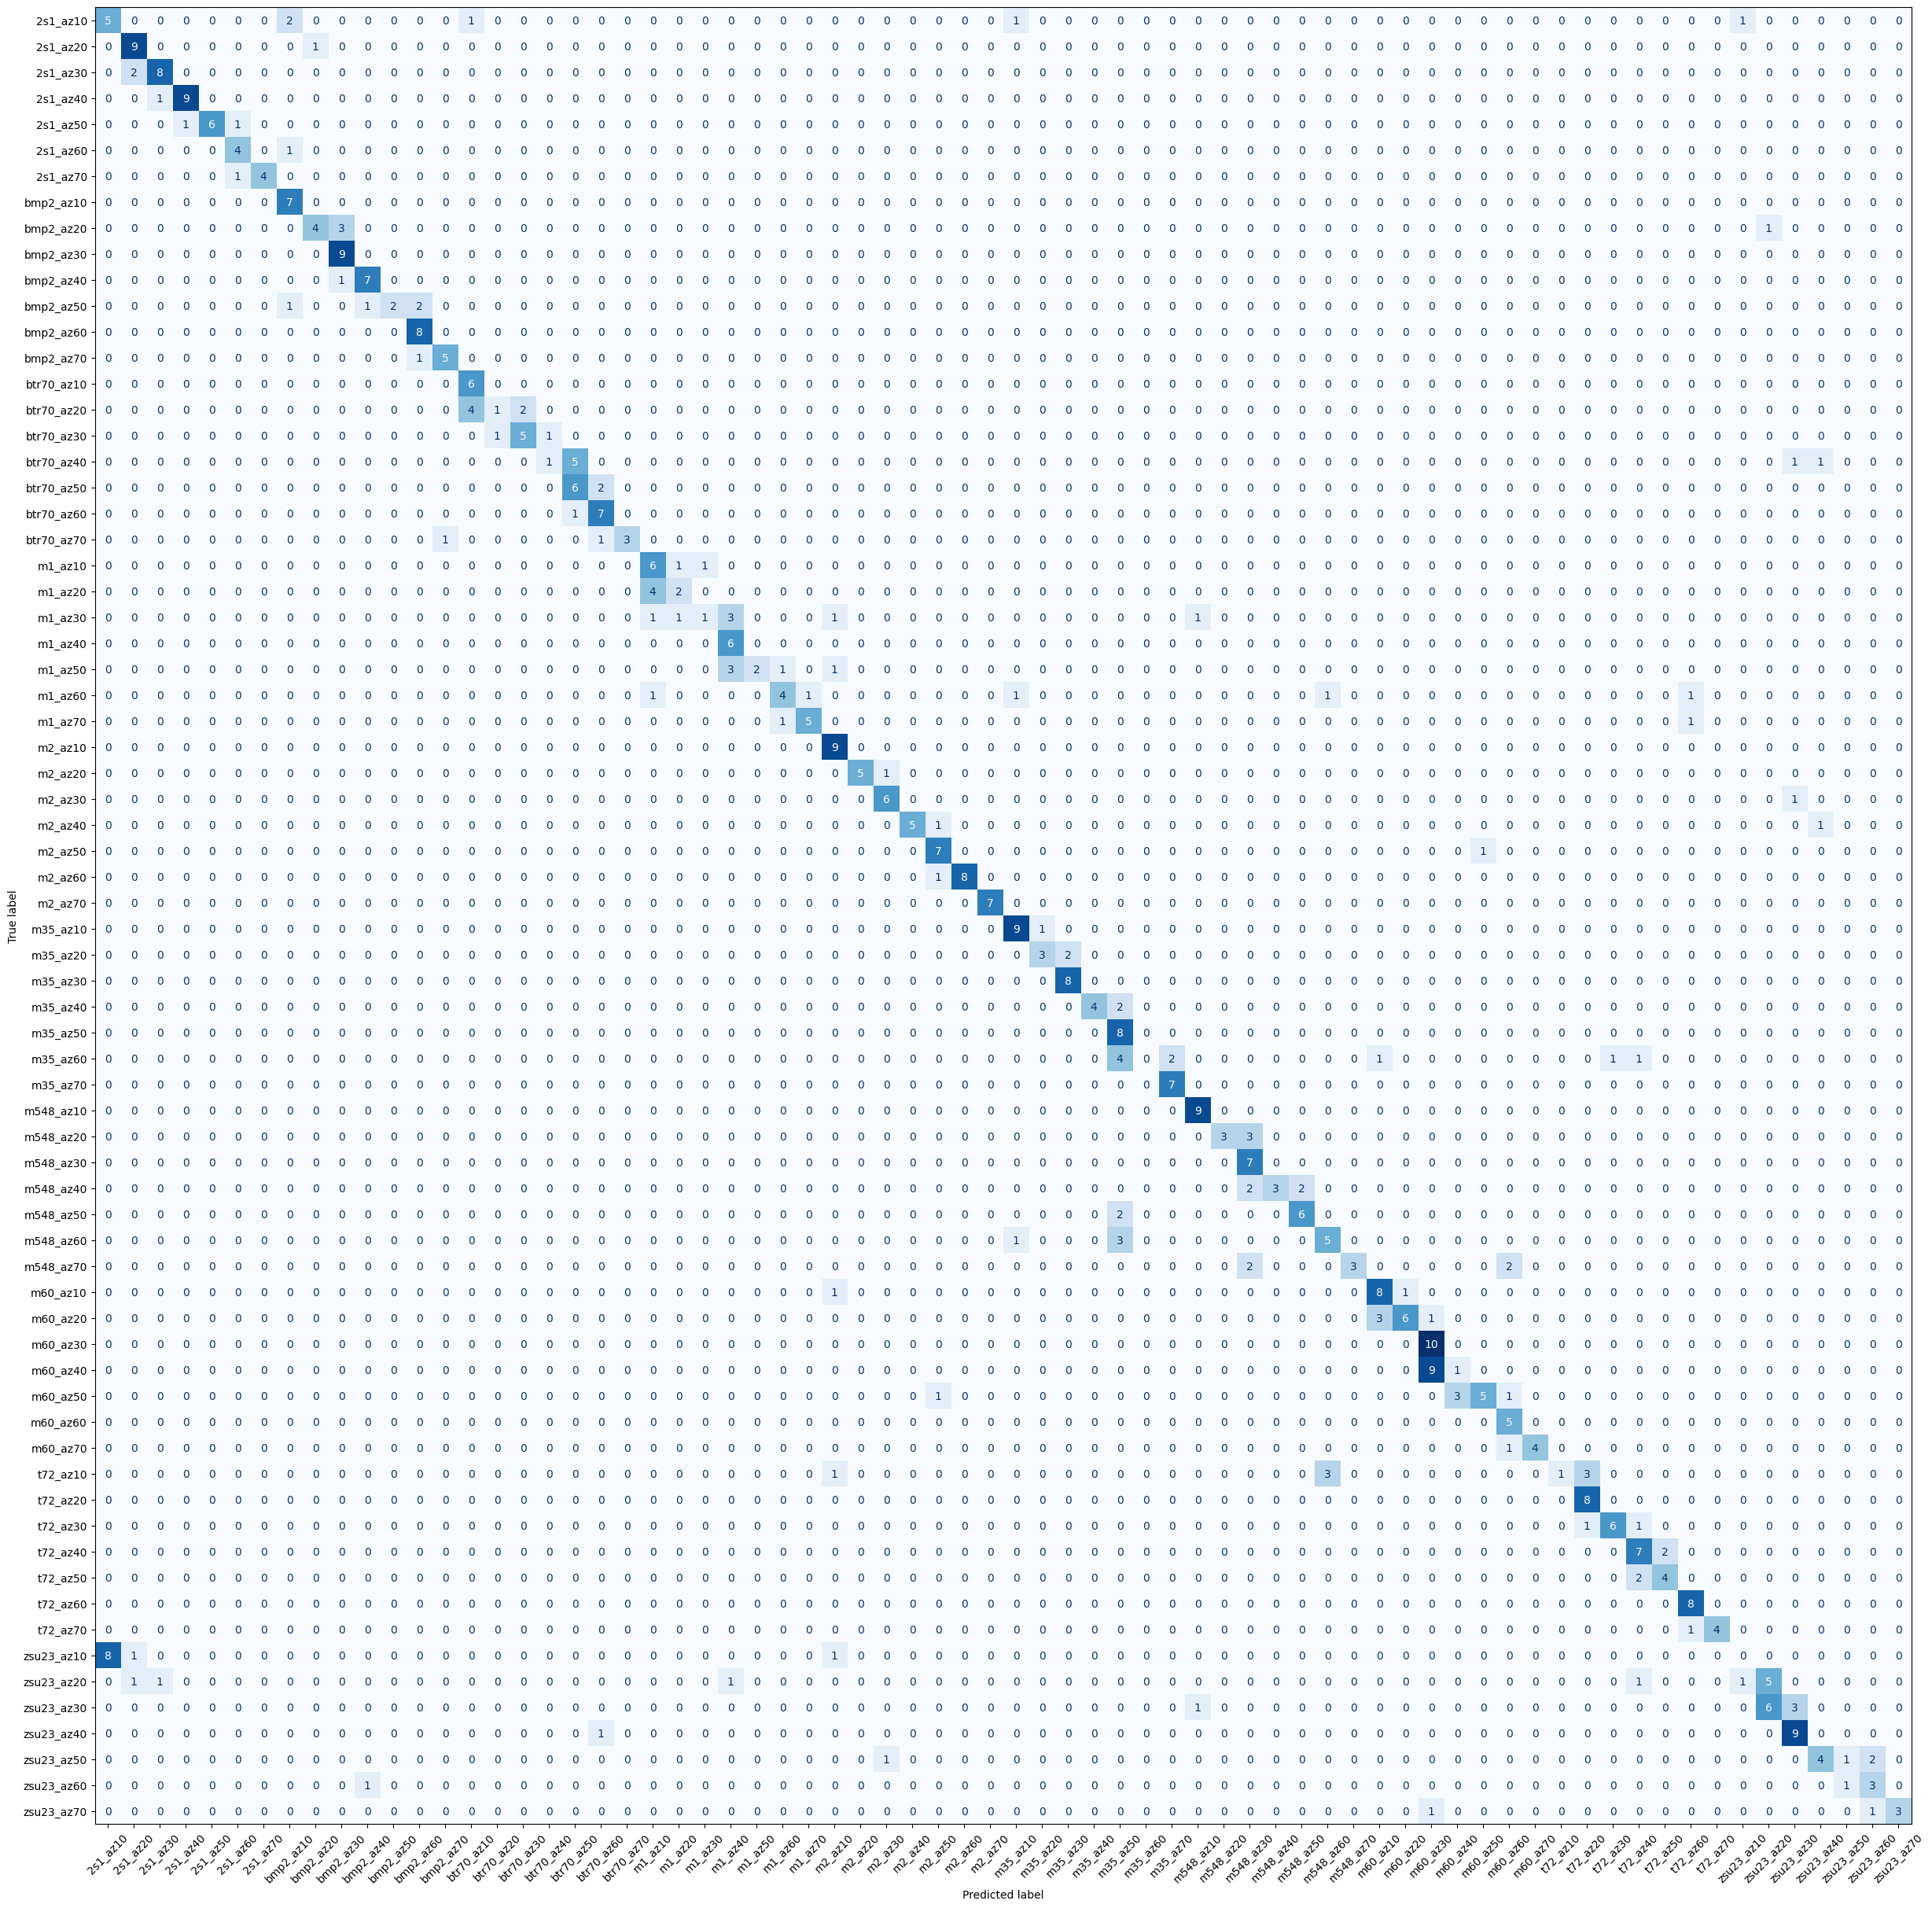

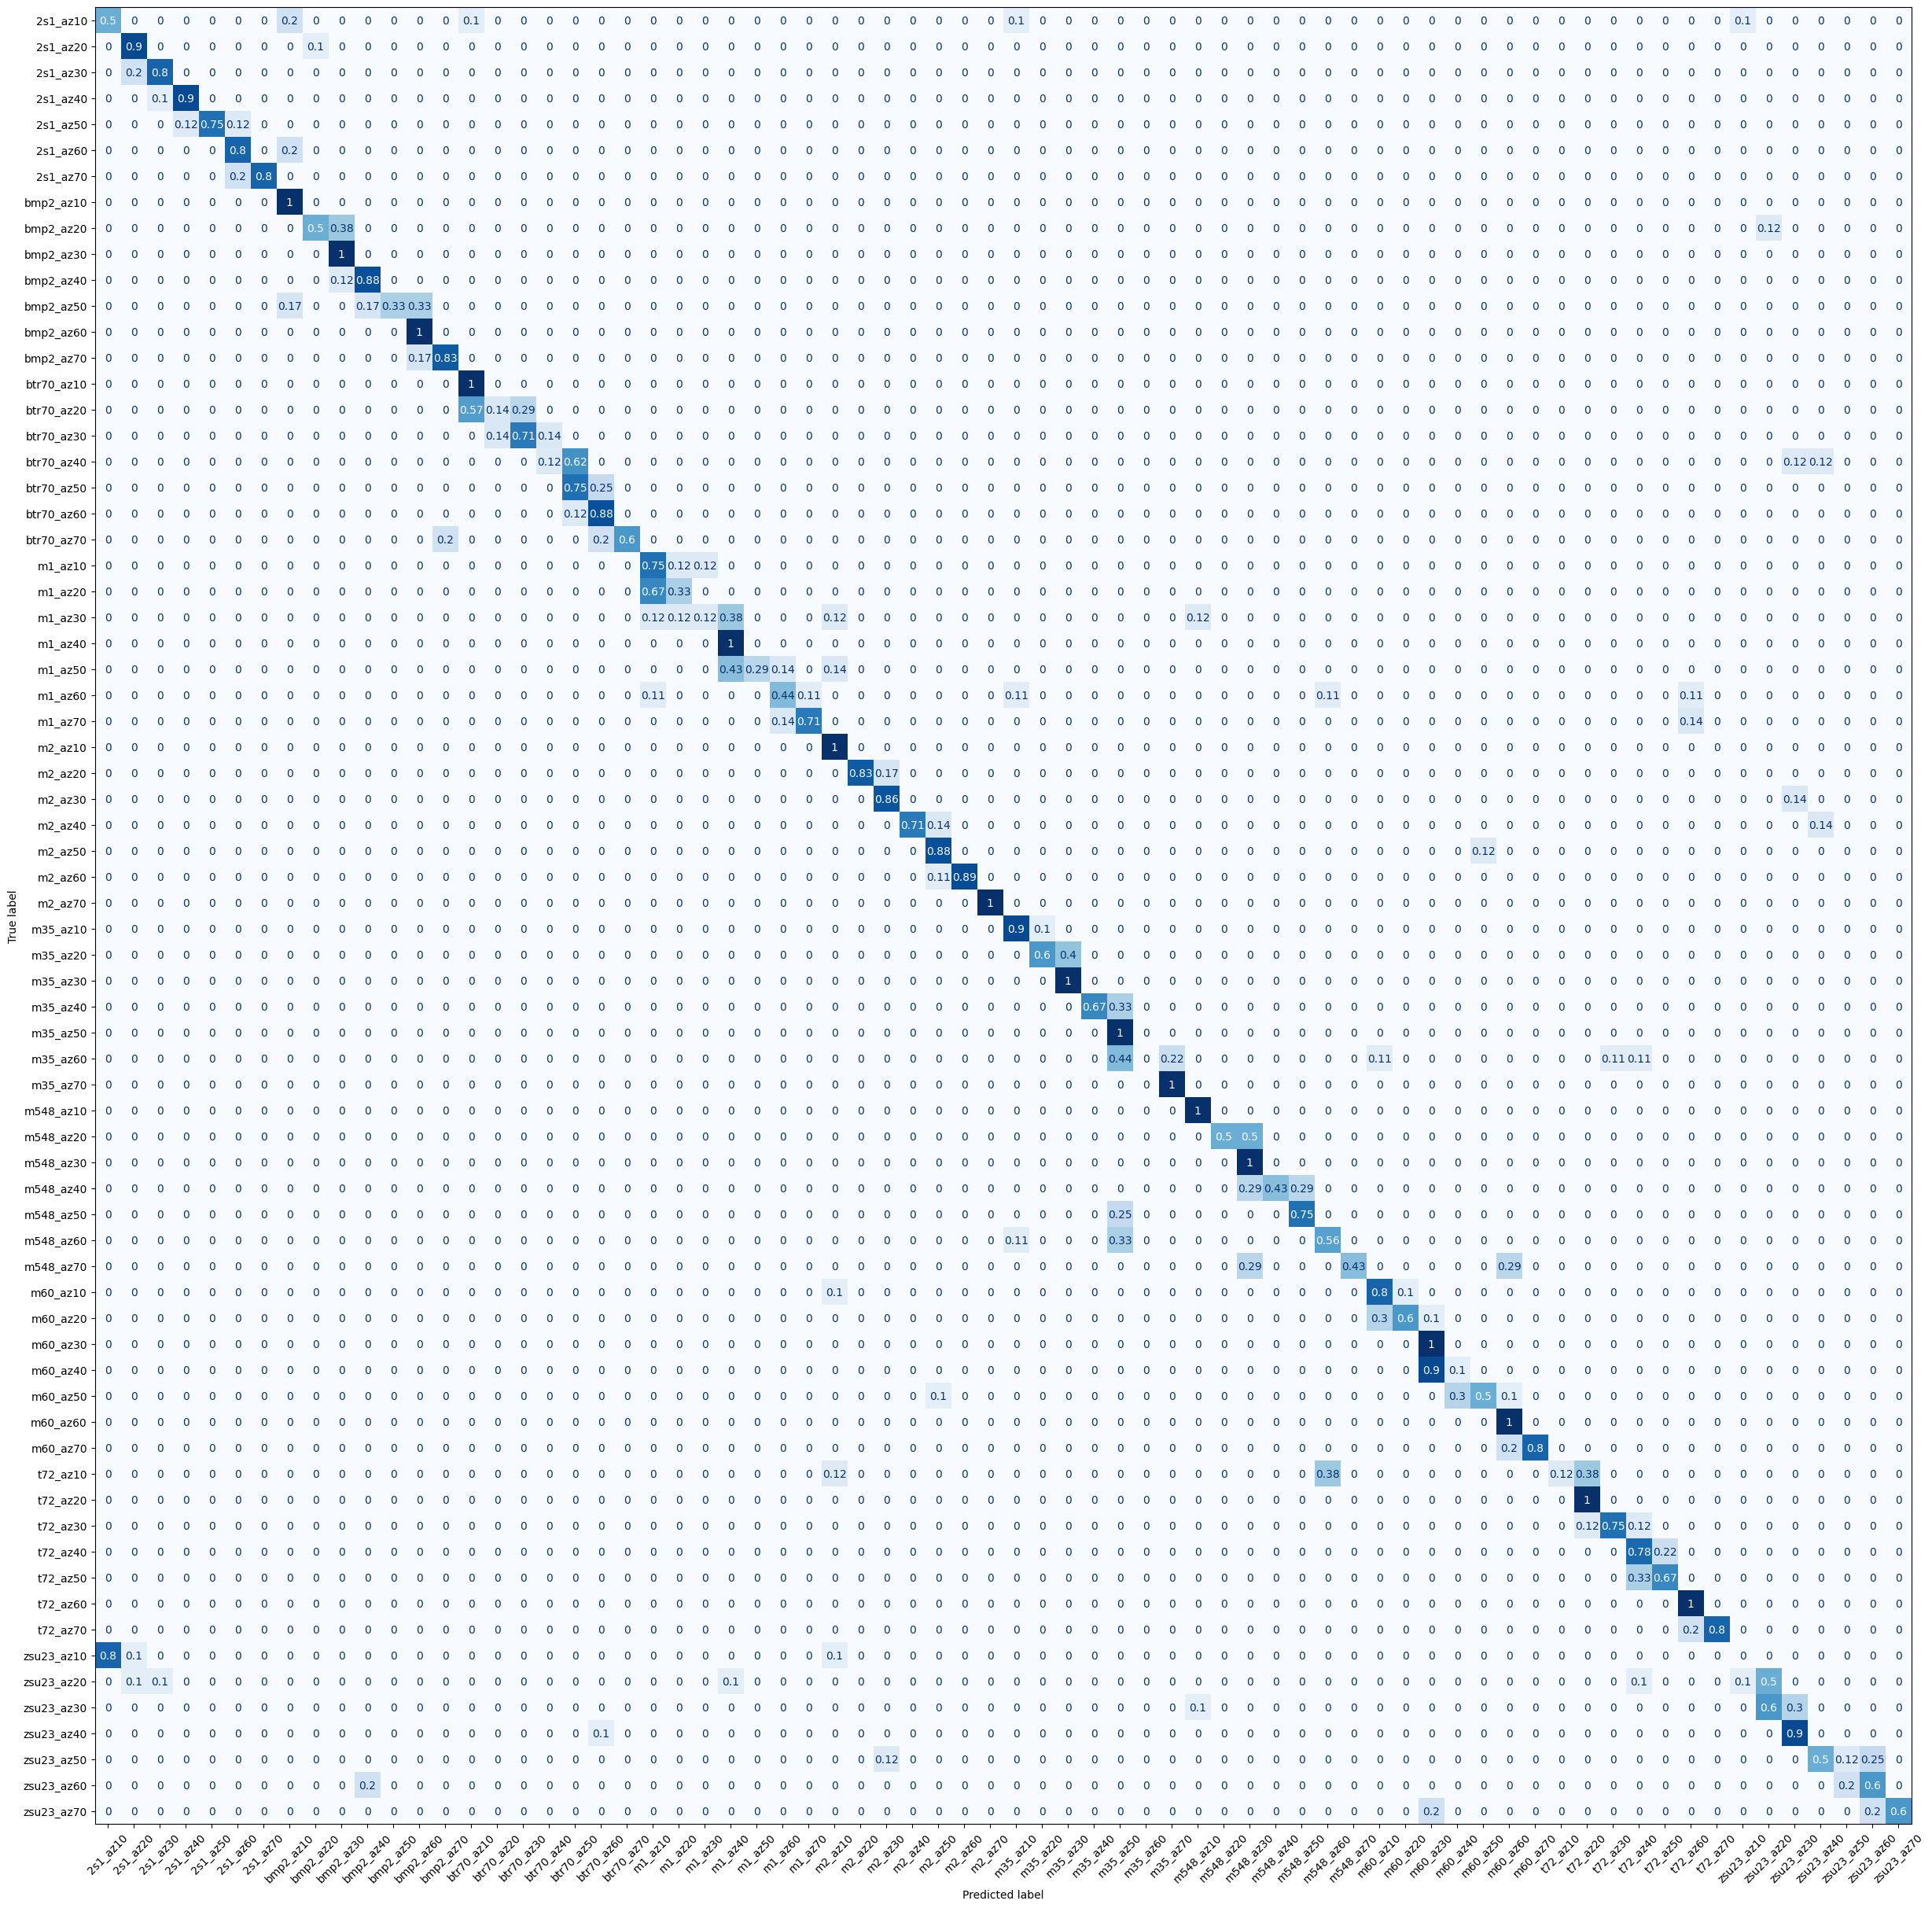

In [14]:
test_dataloader = DataLoader(
    test_ds, batch_size=32, shuffle=False, 
    num_workers=8, pin_memory = True, persistent_workers=True, 
    prefetch_factor=4
                            )

seed = 666
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(test_ds.classes))
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

n_test = len(test_ds)
labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, labels in tqdm(test_dataloader, leave = False):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        batch_size = labels.size(0)
        labels_tensor[idx:idx + batch_size] = labels
        preds_tensor[idx:idx + batch_size] = preds
        idx += batch_size

_labels_all = labels_tensor.cpu().numpy()
_preds_all = preds_tensor.cpu().numpy()

# confusion matrix
cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu  = cp.asnumpy(cm)

disp = ConfusionMatrixDisplay(cm_cpu, display_labels = test_ds.classes)
fig, ax = plt.subplots(figsize=(30, 30))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.tick_params(axis='x', rotation=45)
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize = "true")
cm_norm_cpu  = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = test_ds.classes)
fig, ax = plt.subplots(figsize=(30, 30))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.tick_params(axis='x', rotation=45)
plt.show()

In [15]:
test_dataloader = DataLoader(
    test_ds, batch_size=32, shuffle=False, 
    num_workers=8, pin_memory = True, persistent_workers=True, 
    prefetch_factor=4
                            )

seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i} with seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(test_ds.classes))
    )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    n_test = len(test_ds)
    labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
    preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)

    idx = 0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)

            batch_size = labels.size(0)
            labels_tensor[idx:idx + batch_size] = labels
            preds_tensor[idx:idx + batch_size] = preds
            idx += batch_size

    _labels_tensor = labels_tensor.cpu().numpy()
    _preds_tensor = preds_tensor.cpu().numpy()

    _old_class_labels = np.array([new_to_old_classes[_labels_tensor[i]] for i in range(len(_labels_tensor))])
    _old_class_preds = np.array([new_to_old_classes[_preds_tensor[i]] for i in range(len(_preds_tensor))])

    test_acc = (_old_class_labels == _old_class_preds).mean()
    print(f"Test Accuracy: {test_acc*100:.6f}")
    test_acc_lst.append(test_acc)

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.6f}")
print(f"Max: {test_acc_arr.max() * 100:.6f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.6f}, {test_acc_arr.std() * 100:.6f}")

Evaluating Run 0 with seed 10
Test Accuracy: 90.538033
Evaluating Run 1 with seed 42
Test Accuracy: 91.465677
Evaluating Run 2 with seed 100
Test Accuracy: 91.280148
Evaluating Run 3 with seed 123
Test Accuracy: 91.465677
Evaluating Run 4 with seed 666
Test Accuracy: 89.424861
Evaluating Run 5 with seed 777
Test Accuracy: 90.723562
Evaluating Run 6 with seed 849
Test Accuracy: 88.497217
Evaluating Run 7 with seed 1000
Test Accuracy: 92.207792
Evaluating Run 8 with seed 1111
Test Accuracy: 91.280148
Evaluating Run 9 with seed 1234
Test Accuracy: 92.578850
Min: 88.497217
Max: 92.578850
Avg, Std: 90.946197, 1.163962


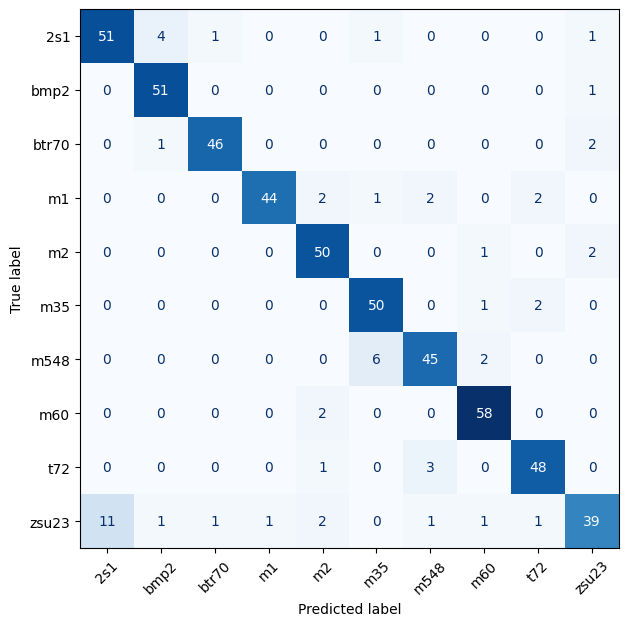

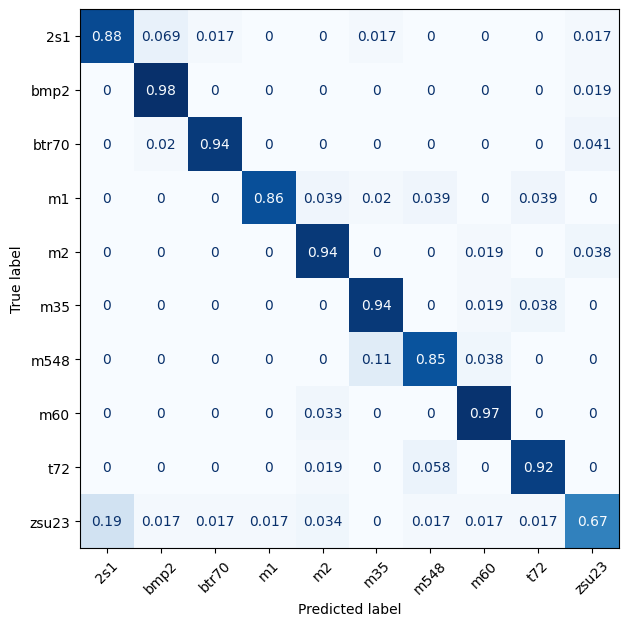

In [17]:
test_dataloader = DataLoader(
    test_ds, batch_size=32, shuffle=False, 
    num_workers=8, pin_memory = True, persistent_workers=True, 
    prefetch_factor=4
                            )

seed = 666
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(test_ds.classes))
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

n_test = len(test_ds)
labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        batch_size = labels.size(0)
        labels_tensor[idx:idx + batch_size] = labels
        preds_tensor[idx:idx + batch_size] = preds
        idx += batch_size        

_labels_all = labels_tensor.cpu().numpy()
_preds_all = preds_tensor.cpu().numpy()

_old_class_labels = np.array([new_to_old_classes[_labels_all[i]] for i in range(len(_labels_all))])
_old_class_preds = np.array([new_to_old_classes[_preds_all[i]] for i in range(len(_preds_all))])

# confusion matrix
cm = confusion_matrix(_old_class_labels, _old_class_preds)
cm_cpu  = cp.asnumpy(cm)

disp = ConfusionMatrixDisplay(cm_cpu, display_labels = test_ds.dataset.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.tick_params(axis='x', rotation=45)
plt.show()

cm_norm = confusion_matrix(_old_class_labels, _old_class_preds, normalize = "true")
cm_norm_cpu  = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = test_ds.dataset.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.tick_params(axis='x', rotation=45)
plt.show()

In [18]:
def make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle, start_lightness=0.3):
    """
    For each vehicle, interpolate from a light tint to the tab10 base colour.
    Returns a flat list of (R,G,B) colours indexed by new_label (bin index).
    """
    tab10 = plt.colormaps["tab10"]
    bin_colors = []
    
    for v in range(n_vehicles):
        base = np.array(tab10(v)[:3])  # RGB of tab10 colour for vehicle v
        white = np.ones(3)
        # linspace from near-white to full colour, n_bins steps
        # start at start_lightness (not pure white) so first bin is still visible
        alphas = np.linspace(start_lightness, 1.0, n_bins_per_vehicle)
        for a in alphas:
            color = (1 - a) * white + a * base
            bin_colors.append(tuple(color))
    
    return bin_colors

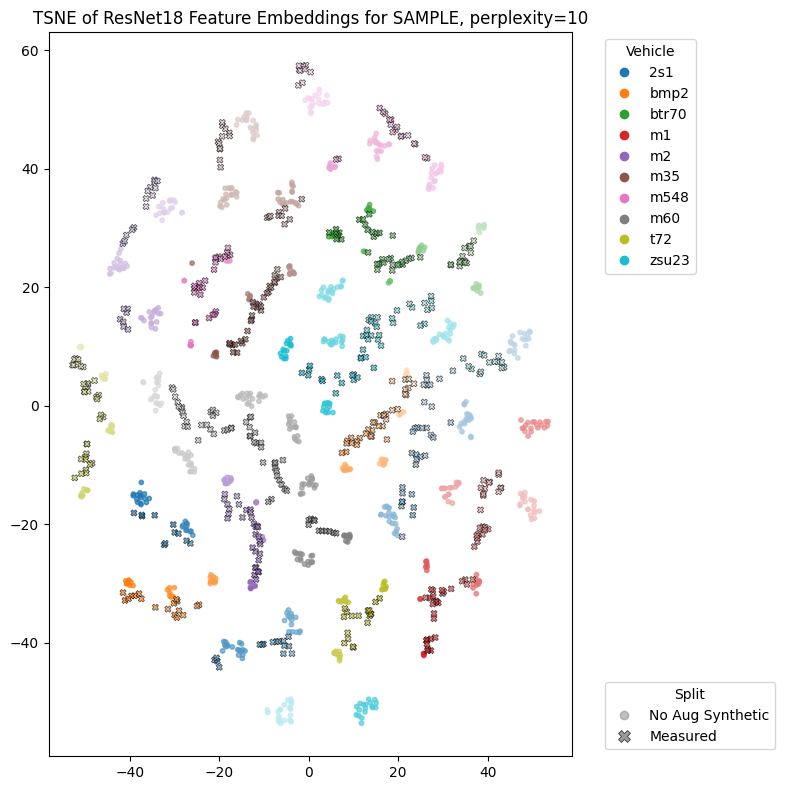

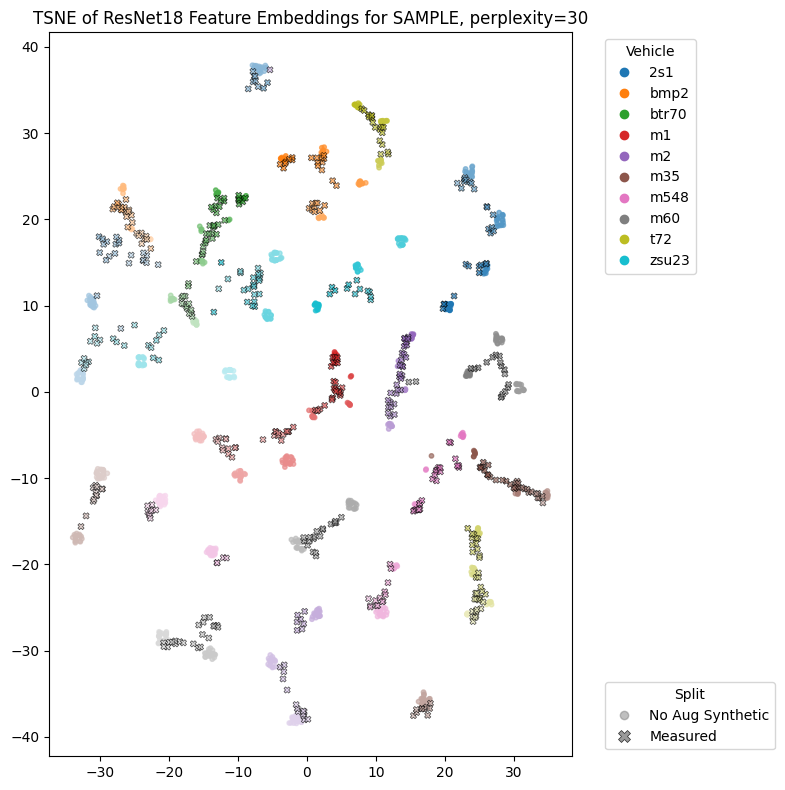

[2026-07-03 21:00:10.135] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


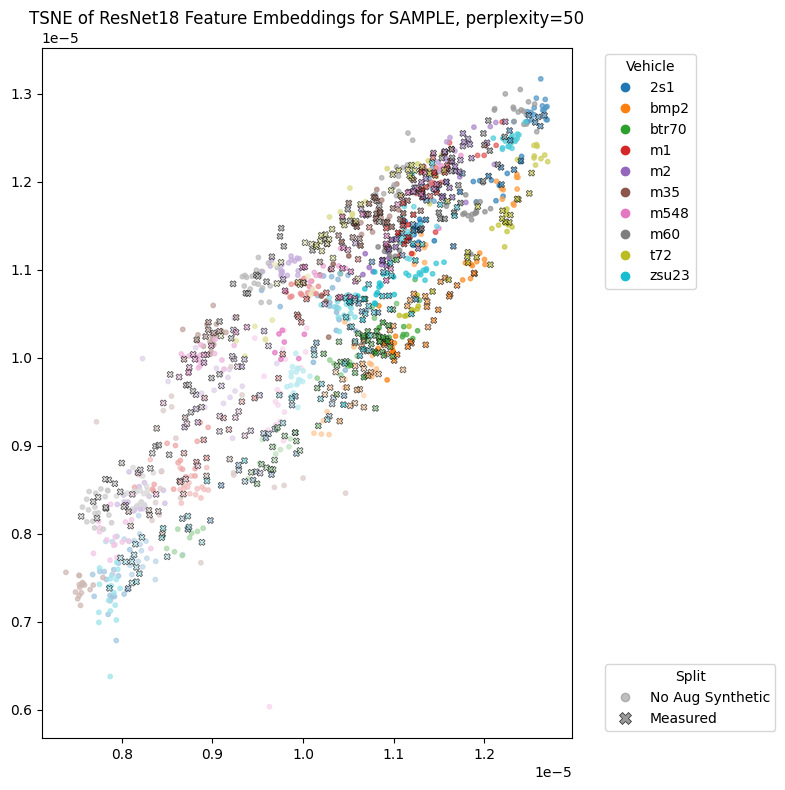

[2026-07-03 21:00:10.276] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...
[2026-07-03 21:00:10.277] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


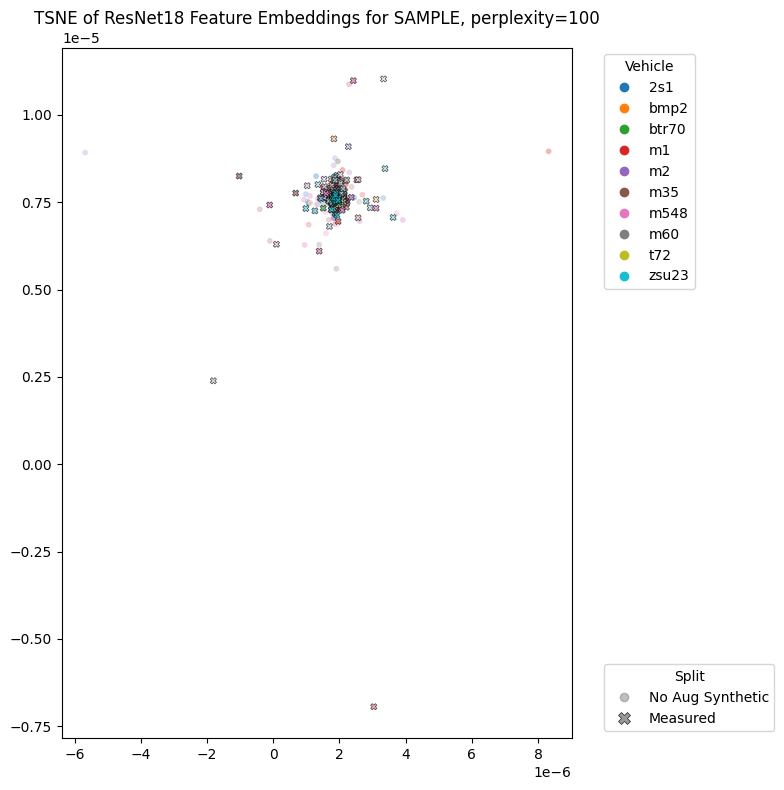

In [19]:
meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_17, bin_width=10)
test_plot_ds =  AzimuthBinnedDataset(meas_ds_17, s, new_classes)

no_aug_synth_ds_14_15_16 = filter_by_elev(no_aug_synth_ds, {14, 15, 16})
s, b, total_bins, new_classes_train, new_to_old_classes_train = build_azimuth_bin_map(no_aug_synth_ds_14_15_16, bin_width=10)
train_plot_ds =  AzimuthBinnedDataset(no_aug_synth_ds_14_15_16, s, new_classes_train)

combined_ds = ConcatDataset([train_plot_ds, test_plot_ds])
combined_loader = DataLoader(combined_ds, batch_size=32, shuffle=False, num_workers=8, prefetch_factor = 4, pin_memory=True, persistent_workers=True)

seed = 10
set_seed(seed)

device = torch.device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_plot_ds.classes))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

n_samples = len(combined_ds)
features_tensor = torch.zeros((n_samples, 512), device = device)
labels_tensor = torch.zeros(n_samples, dtype = torch.long, device = device)

idx = 0
with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        
        bs = feats.size(0)
        features_tensor[idx: idx+bs] = feats
        labels_tensor[idx: idx+bs] = targets.to(device)
        idx += bs            

torch.cuda.synchronize()

_features = features_tensor.cpu().numpy()
_labels = labels_tensor.cpu().numpy()

for num in [10, 30, 50, 100]:
    
    tsne = TSNE(
        n_components=2,
        perplexity=num,
        learning_rate_method="adaptive",
        metric = "cosine"
    )

    features_2d = tsne.fit_transform(_features)

    n_vehicles = len(train_plot_ds.dataset.classes)
    n_bins_per_vehicle = total_bins // n_vehicles 

    bin_colors = make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle)

    def labels_to_colors(label_array, bin_colors):
        return [bin_colors[l] for l in label_array]

    train_colors = labels_to_colors(_labels[:len(train_plot_ds)], bin_colors)
    test_colors  = labels_to_colors(_labels[len(train_plot_ds):], bin_colors)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d[:len(train_plot_ds), 0],
        features_2d[:len(train_plot_ds), 1],
        c=train_colors,
        s=10,
        alpha=0.7,
        marker = "o"
    )

    plt.scatter(
        features_2d[len(train_plot_ds):, 0],
        features_2d[len(train_plot_ds):, 1],
        c=test_colors,
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k"
    )

    tab10 = plt.colormaps["tab10"]
    vehicle_handles = [
        Line2D([0], [0], marker="o", color=tab10(v), linestyle="None",
            markersize=6, label=train_plot_ds.dataset.classes[v])
        for v in range(n_vehicles)
    ]
    class_legend = plt.legend(handles=vehicle_handles, title="Vehicle",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.add_artist(class_legend)

    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"TSNE of ResNet18 Feature Embeddings for SAMPLE, perplexity={num}")
    plt.tight_layout()
    plt.show()

[2026-07-03 21:03:14.287] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


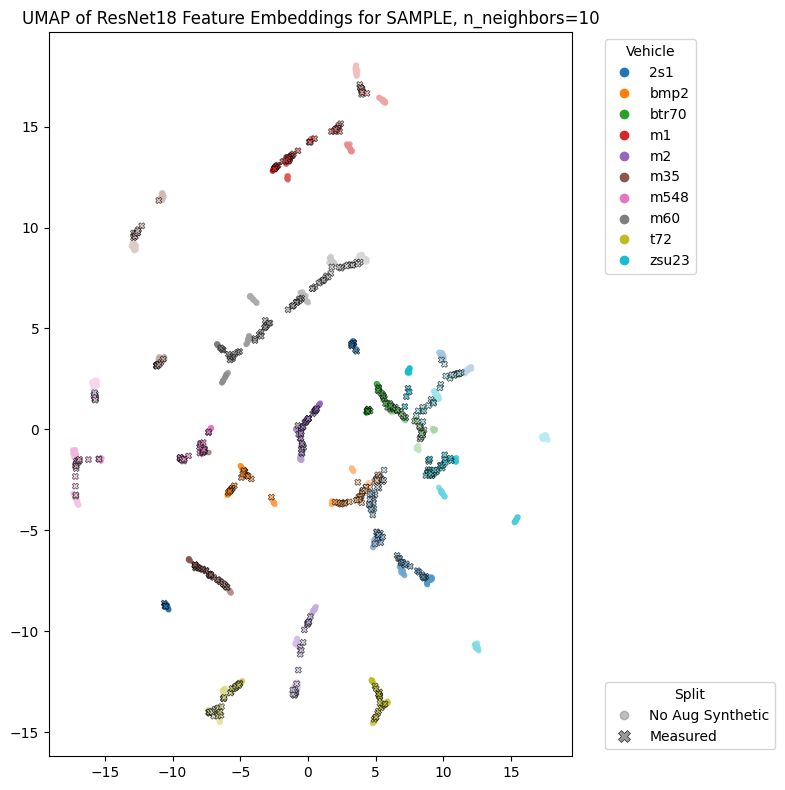

[2026-07-03 21:03:15.058] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


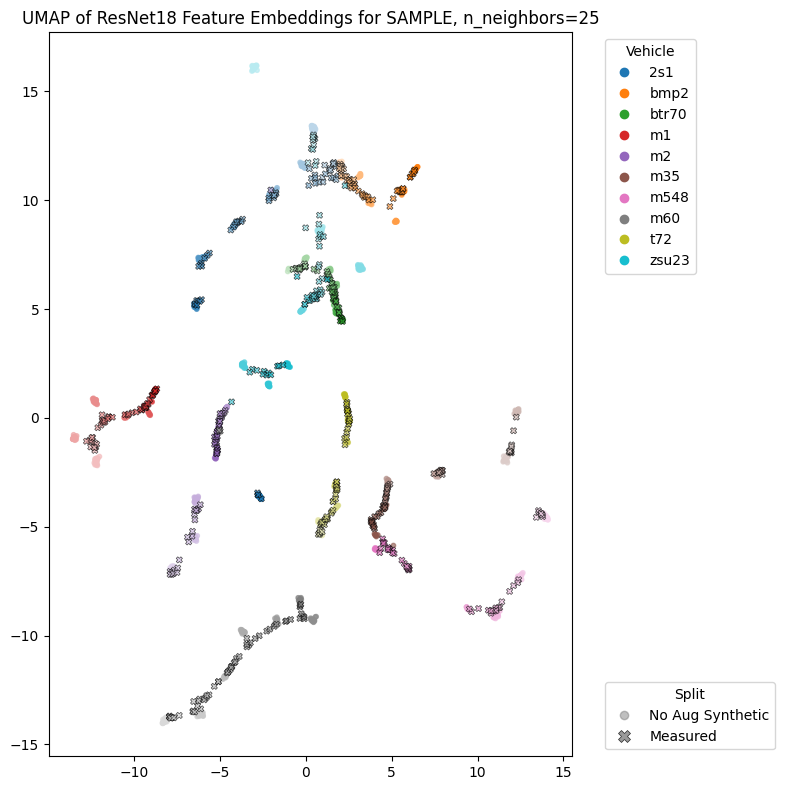

[2026-07-03 21:03:15.239] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


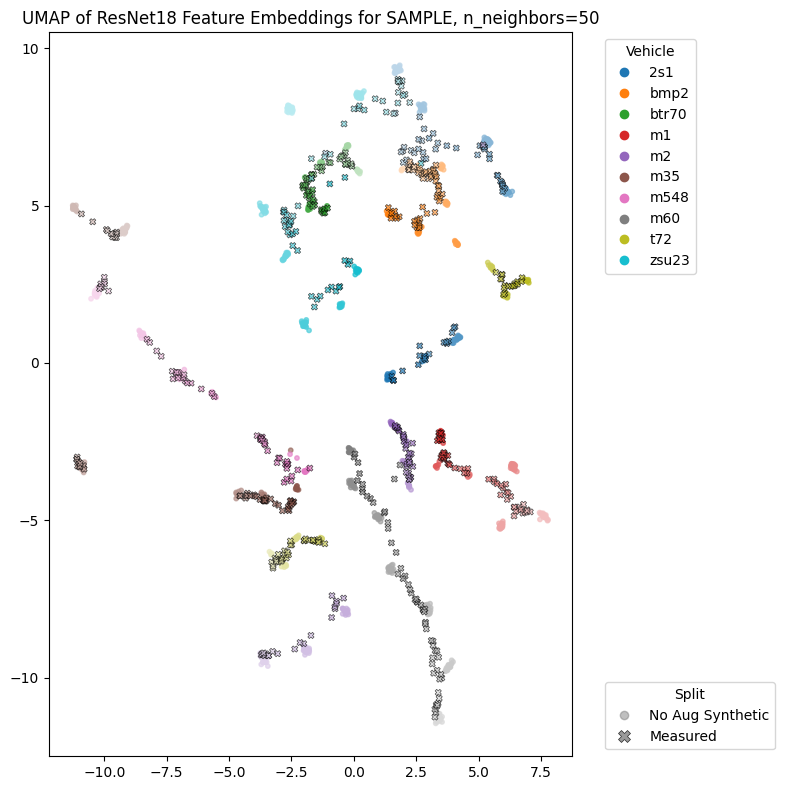

[2026-07-03 21:03:15.396] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


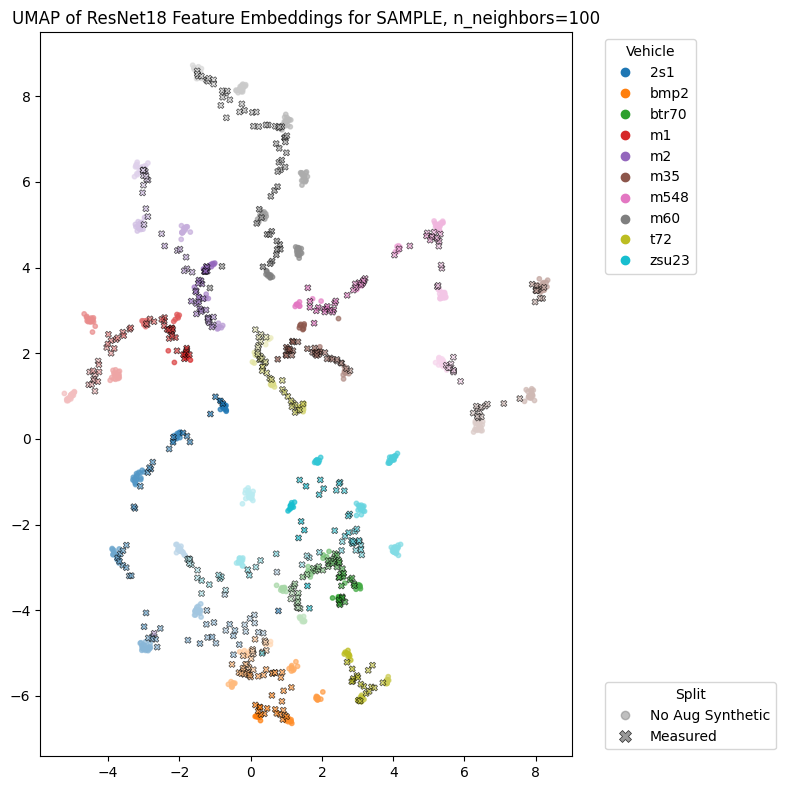

In [20]:
meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_17, bin_width=10)
test_plot_ds =  AzimuthBinnedDataset(meas_ds_17, s, new_classes)

no_aug_synth_ds_14_15_16 = filter_by_elev(no_aug_synth_ds, {14, 15, 16})
s, b, total_bins, new_classes_train, new_to_old_classes_train = build_azimuth_bin_map(no_aug_synth_ds_14_15_16, bin_width=10)
train_plot_ds =  AzimuthBinnedDataset(no_aug_synth_ds_14_15_16, s, new_classes_train)

combined_ds = ConcatDataset([train_plot_ds, test_plot_ds])
combined_loader = DataLoader(combined_ds, batch_size=32, shuffle=False, num_workers=8, prefetch_factor = 4, pin_memory=True, persistent_workers=True)

seed = 10
set_seed(seed)

device = torch.device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_plot_ds.classes))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

n_samples = len(combined_ds)
features_tensor = torch.zeros((n_samples, 512), device = device)
labels_tensor = torch.zeros(n_samples, dtype = torch.long, device = device)

idx = 0
with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        
        bs = feats.size(0)
        features_tensor[idx: idx+bs] = feats
        labels_tensor[idx: idx+bs] = targets.to(device)
        idx += bs            

torch.cuda.synchronize()

_features = features_tensor.cpu().numpy()
_labels = labels_tensor.cpu().numpy()

for num in [10, 25, 50, 100]:
    
    reducer = UMAP(
        n_neighbors=num,
        min_dist=0.25,
        n_components=2,
        metric = "cosine"
    )

    features_2d_umap = reducer.fit_transform(_features)

    n_vehicles = len(train_plot_ds.dataset.classes)
    n_bins_per_vehicle = total_bins // n_vehicles 

    bin_colors = make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle)

    def labels_to_colors(label_array, bin_colors):
        return [bin_colors[l] for l in label_array]

    train_colors = labels_to_colors(_labels[:len(train_plot_ds)], bin_colors)
    test_colors  = labels_to_colors(_labels[len(train_plot_ds):], bin_colors)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d_umap[:len(train_plot_ds), 0],
        features_2d_umap[:len(train_plot_ds), 1],
        c=train_colors,
        s=10,
        alpha=0.7,
        marker = "o"
    )

    plt.scatter(
        features_2d_umap[len(train_plot_ds):, 0],
        features_2d_umap[len(train_plot_ds):, 1],
        c=test_colors,
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k"
    )

    tab10 = plt.colormaps["tab10"]
    vehicle_handles = [
        Line2D([0], [0], marker="o", color=tab10(v), linestyle="None",
            markersize=6, label=train_plot_ds.dataset.classes[v])
        for v in range(n_vehicles)
    ]
    class_legend = plt.legend(handles=vehicle_handles, title="Vehicle",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.add_artist(class_legend)

    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"UMAP of ResNet18 Feature Embeddings for SAMPLE, n_neighbors={num}")
    plt.tight_layout()
    plt.show()

In [22]:
no_aug_synth_ds_14_15_16 = filter_by_elev(no_aug_synth_ds, {14, 15, 16})
s, b, total_bins, new_classes_train, new_to_old_classes_train = build_azimuth_bin_map(no_aug_synth_ds_14_15_16, bin_width=10)
new_no_aug_synth_ds_14_15_16 = AzimuthBinnedDataset(no_aug_synth_ds_14_15_16, s, new_classes_train)

meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes_test, new_to_old_classes_test = build_azimuth_bin_map(meas_ds_17, bin_width=10)
new_meas_ds_17 = AzimuthBinnedDataset(meas_ds_17, s, new_classes_test)

seed = 10
set_seed(seed)

device = torch.device("cuda:0")
torch.cuda.set_device(device)

# ── Model ────────────────────────────────────────────────────────────────────
new_model = models.resnet18(weights=None)
new_model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(new_model.fc.in_features, len(new_SSR_synth_ds_14_15_16.classes))
)
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80.pth"),
    map_location=device
))
new_model = new_model.to(device).eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1]).to(device).eval()

# ── SSR aug synth — 200 epoch accumulation ───────────────────────────────────
SSR_synth_loader = DataLoader(
    train_ds, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_synth = len(train_ds)
SSR_synth_feats_gpu  = torch.zeros((75 * n_synth, 512), device=device)
SSR_synth_labels_gpu = torch.zeros(75 * n_synth, dtype=torch.long, device=device)

idx = 0
for epoch in tqdm(range(75), leave=False, position=0, desc="Epochs"):
    with torch.no_grad():
        for inputs, targets in SSR_synth_loader:
            inputs = inputs.to(device)
            feats = feature_extractor(inputs).view(inputs.size(0), -1)
            bs = feats.size(0)
            SSR_synth_feats_gpu[idx:idx+bs]  = feats
            SSR_synth_labels_gpu[idx:idx+bs] = targets.to(device)
            idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving data to CPU

SSR_synth_feats  = SSR_synth_feats_gpu.cpu().numpy()
SSR_synth_labels = SSR_synth_labels_gpu.cpu().numpy()

# ── no aug synth — single pass ───────────────────────────────────────────────────────
synth_loader = DataLoader(
    new_no_aug_synth_ds_14_15_16, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_no_aug_synth = len(new_no_aug_synth_ds_14_15_16)
synth_feats_gpu  = torch.zeros((n_no_aug_synth, 512), device=device)
synth_labels_gpu = torch.zeros(n_no_aug_synth, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, targets in tqdm(synth_loader, leave=False):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs).view(inputs.size(0), -1)
        bs = feats.size(0)
        synth_feats_gpu[idx:idx+bs]  = feats
        synth_labels_gpu[idx:idx+bs] = targets.to(device)
        idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving data to CPU

synth_feats  = synth_feats_gpu.cpu().numpy()
synth_labels = synth_labels_gpu.cpu().numpy()

# ── meas — single pass ───────────────────────────────────────────────────────
meas_loader = DataLoader(
    new_meas_ds_17, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_meas = len(new_meas_ds_17)
meas_feats_gpu  = torch.zeros((n_meas, 512), device=device)
meas_labels_gpu = torch.zeros(n_meas, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, targets in tqdm(meas_loader, leave=False):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs).view(inputs.size(0), -1)
        bs = feats.size(0)
        meas_feats_gpu[idx:idx+bs]  = feats
        meas_labels_gpu[idx:idx+bs] = targets.to(device)
        idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving data to CPU

meas_feats  = meas_feats_gpu.cpu().numpy()
meas_labels = meas_labels_gpu.cpu().numpy()

del SSR_synth_feats_gpu, SSR_synth_labels_gpu
del synth_feats_gpu, synth_labels_gpu  
del meas_feats_gpu, meas_labels_gpu
torch.cuda.empty_cache()

# np.savez_compressed(
#     os.path.join(workspace, "weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/seed10_feats_labels.npz"),
#     SSR_synth_feats=SSR_synth_feats,
#     SSR_synth_labels=SSR_synth_labels,
#     synth_feats=synth_feats,
#     synth_labels=synth_labels,
#     meas_feats=meas_feats,
#     meas_labels=meas_labels
# )

In [23]:
combined_feats = np.concatenate([SSR_synth_feats,  meas_feats],  axis=0)
combined_labels = np.concatenate([SSR_synth_labels, meas_labels], axis=0)

for val in [10, 25, 30, 50, 100]:
    pca = PCA(n_components = val)
    combined_feats_pca = pca.fit_transform(combined_feats)
    print(f"Variance explained using {val} components: {pca.explained_variance_ratio_.sum():.3f}")

Variance explained using 10 components: 0.528
Variance explained using 25 components: 0.877
Variance explained using 30 components: 0.917
Variance explained using 50 components: 0.960
Variance explained using 100 components: 0.981


Variance explained using 50 components: 0.960
[2026-07-03 21:19:59.417] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 21:19:59.448] [CUML] [debug] Computing KNN Graph
[2026-07-03 21:20:01.989] [CUML] [debug] Computing fuzzy simplicial set


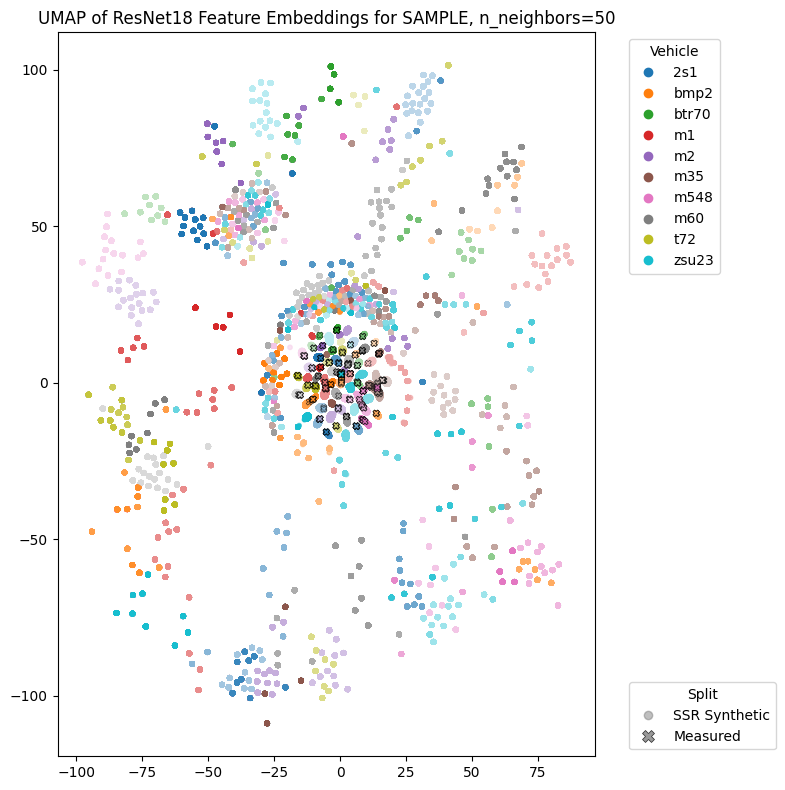

[2026-07-03 21:20:07.625] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 21:20:07.653] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-03 21:20:07.660] [CUML] [debug] Computing KNN Graph
[2026-07-03 21:20:10.865] [CUML] [debug] Computing fuzzy simplicial set


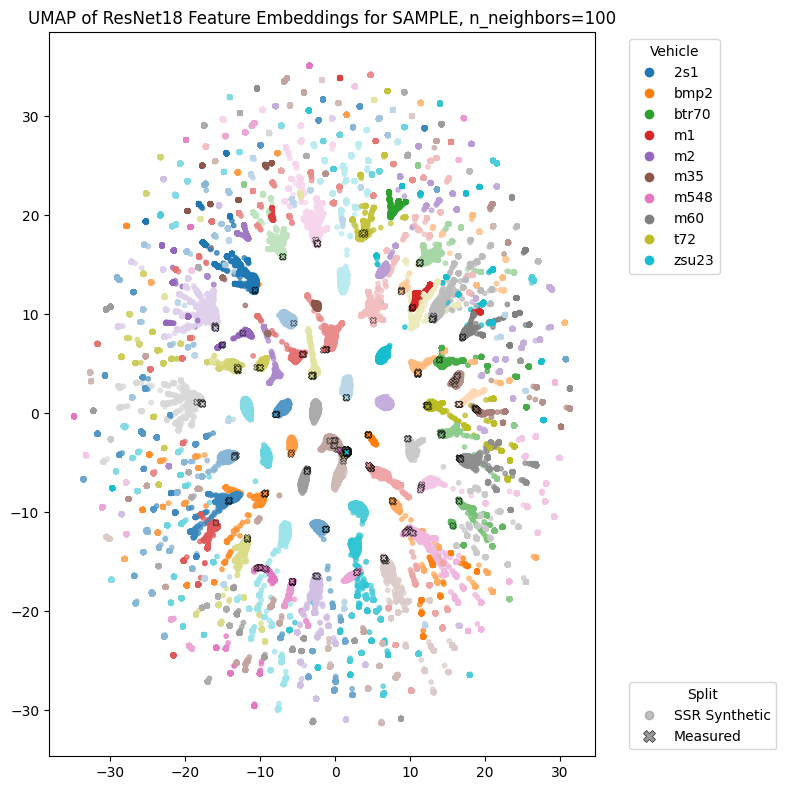

[2026-07-03 21:20:16.371] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 21:20:16.401] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-03 21:20:16.401] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree
[2026-07-03 21:20:16.416] [CUML] [debug] Computing KNN Graph
[2026-07-03 21:20:21.092] [CUML] [debug] Computing fuzzy simplicial set


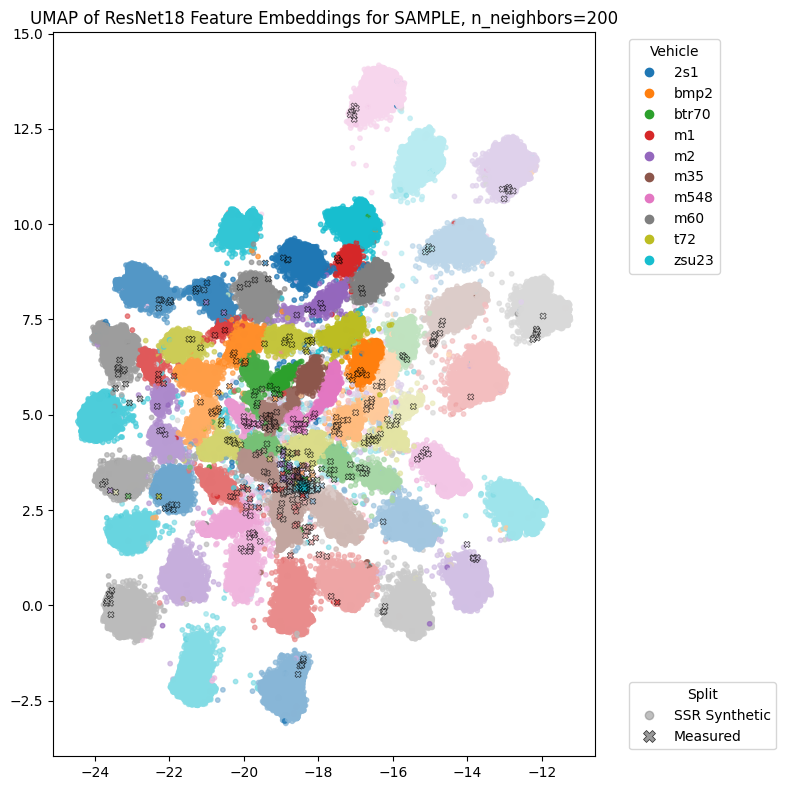

[2026-07-03 21:20:32.687] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 21:20:32.722] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-03 21:20:32.722] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree
[2026-07-03 21:20:32.736] [CUML] [debug] Computing KNN Graph
[2026-07-03 21:20:37.694] [CUML] [debug] Computing fuzzy simplicial set


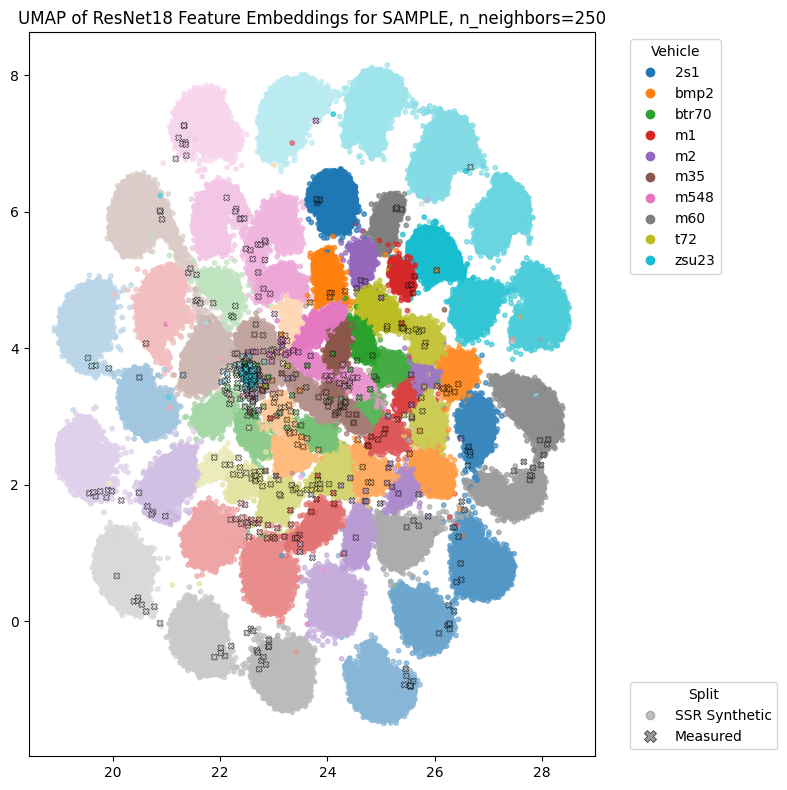

[2026-07-03 21:20:52.988] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 21:20:53.020] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-03 21:20:53.020] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree
[2026-07-03 21:20:53.038] [CUML] [debug] Computing KNN Graph
[2026-07-03 21:20:58.400] [CUML] [debug] Computing fuzzy simplicial set


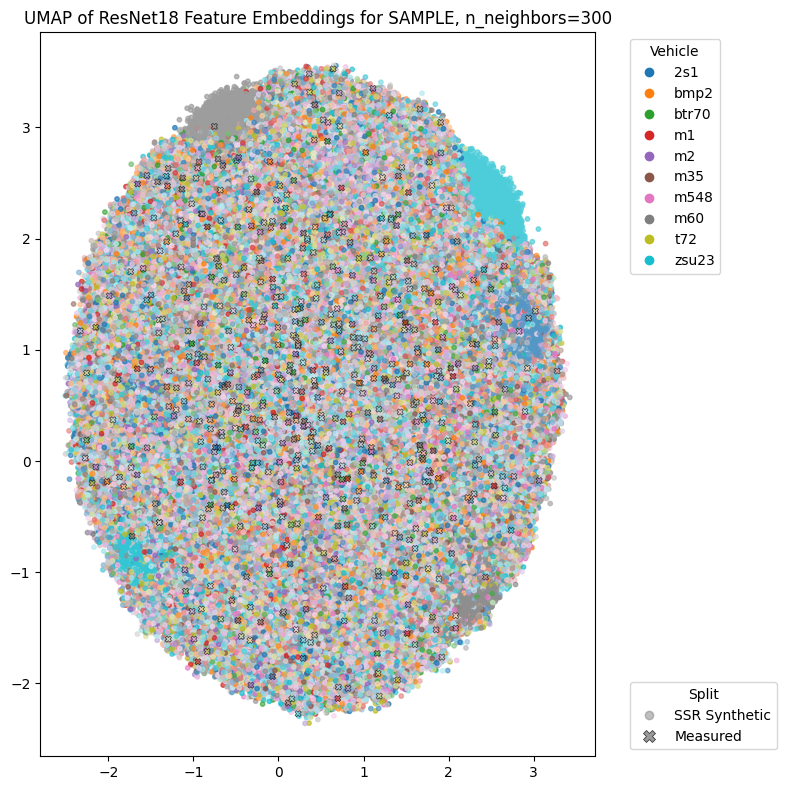

In [24]:
combined_feats = np.concatenate([SSR_synth_feats,  meas_feats],  axis=0)
combined_labels = np.concatenate([SSR_synth_labels, meas_labels], axis=0)

pca = PCA(n_components = 50)
combined_feats_pca = pca.fit_transform(combined_feats)
print(f"Variance explained using 50 components: {pca.explained_variance_ratio_.sum():.3f}")


for num in [50, 100, 200, 250, 300]:
    
    reducer = UMAP(
            n_neighbors=num,
            min_dist=0.25,
            n_components=2,
            metric = "cosine",
            verbose=True
        )

    features_2d_umap = reducer.fit_transform(combined_feats_pca)

    n_vehicles = len(no_aug_synth_ds_14_15_16.classes)
    n_bins_per_vehicle = total_bins // n_vehicles 

    bin_colors = make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle)

    def labels_to_colors(label_array, bin_colors):
        return [bin_colors[l] for l in label_array]

    train_colors = labels_to_colors(combined_labels[:len(SSR_synth_feats)], bin_colors)
    test_colors  = labels_to_colors(combined_labels[len(SSR_synth_feats):], bin_colors)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d_umap[:len(SSR_synth_feats), 0],
        features_2d_umap[:len(SSR_synth_feats), 1],
        c=train_colors,
        s=10,
        alpha=0.7,
        marker = "o"
    )

    plt.scatter(
        features_2d_umap[len(SSR_synth_feats):, 0],
        features_2d_umap[len(SSR_synth_feats):, 1],
        c=test_colors,
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k"
    )

    tab10 = plt.colormaps["tab10"]
    vehicle_handles = [
        Line2D([0], [0], marker="o", color=tab10(v), linestyle="None",
            markersize=6, label=new_SSR_synth_ds_14_15_16.dataset.classes[v])
        for v in range(n_vehicles)
    ]
    class_legend = plt.legend(handles=vehicle_handles, title="Vehicle",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.add_artist(class_legend)

    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="SSR Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"UMAP of ResNet18 Feature Embeddings for SAMPLE, n_neighbors={num}")
    plt.tight_layout()
    plt.show()

In [25]:
combined_feats = np.concatenate([SSR_synth_feats,  synth_feats, meas_feats],  axis=0)
combined_labels = np.concatenate([SSR_synth_labels,  synth_labels, meas_labels], axis=0)

for val in [10, 25, 30, 50, 100]:
    pca = PCA(n_components = val)
    combined_feats_pca = pca.fit_transform(combined_feats)
    print(f"Variance explained using {val} components: {pca.explained_variance_ratio_.sum():.3f}")

Variance explained using 10 components: 0.528
Variance explained using 25 components: 0.877
Variance explained using 30 components: 0.917
Variance explained using 50 components: 0.960
Variance explained using 100 components: 0.981


Variance explained using 50 components: 0.960
[2026-07-03 21:24:50.499] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')


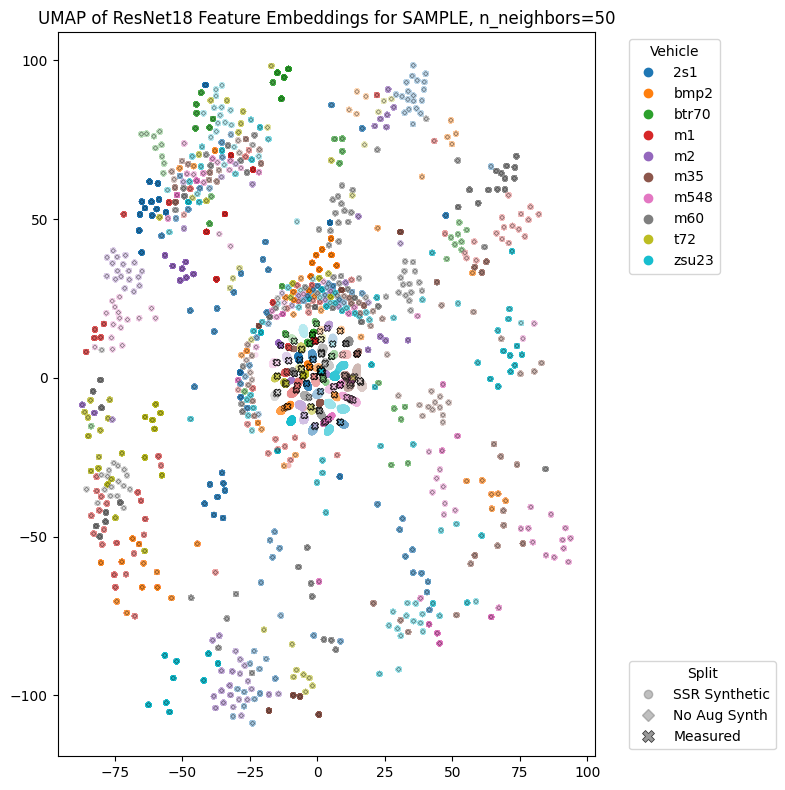

[2026-07-03 21:24:58.638] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 21:24:58.664] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.


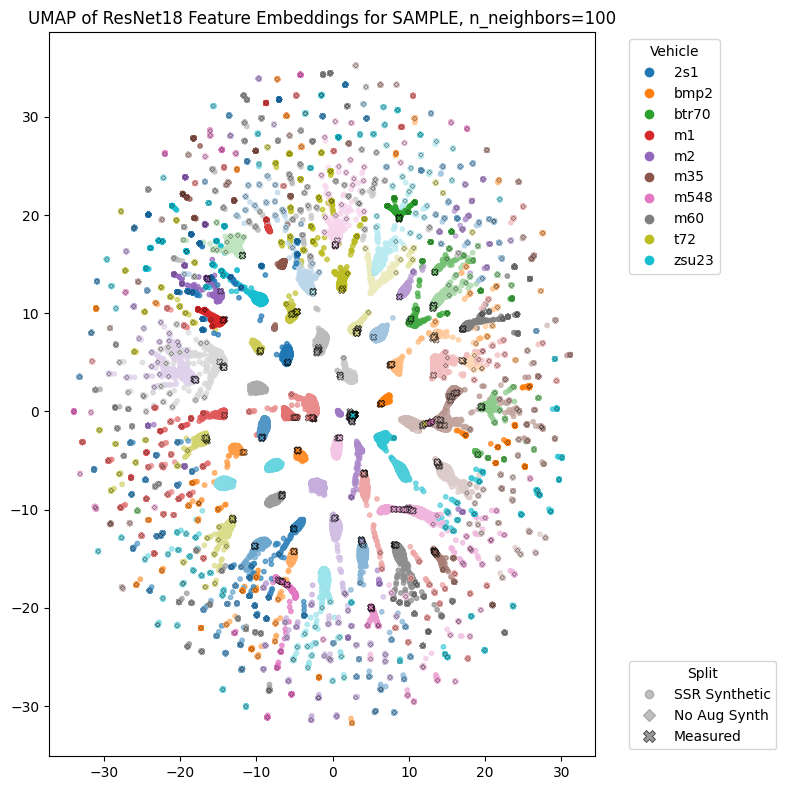

[2026-07-03 21:25:10.151] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 21:25:10.180] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-03 21:25:10.180] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


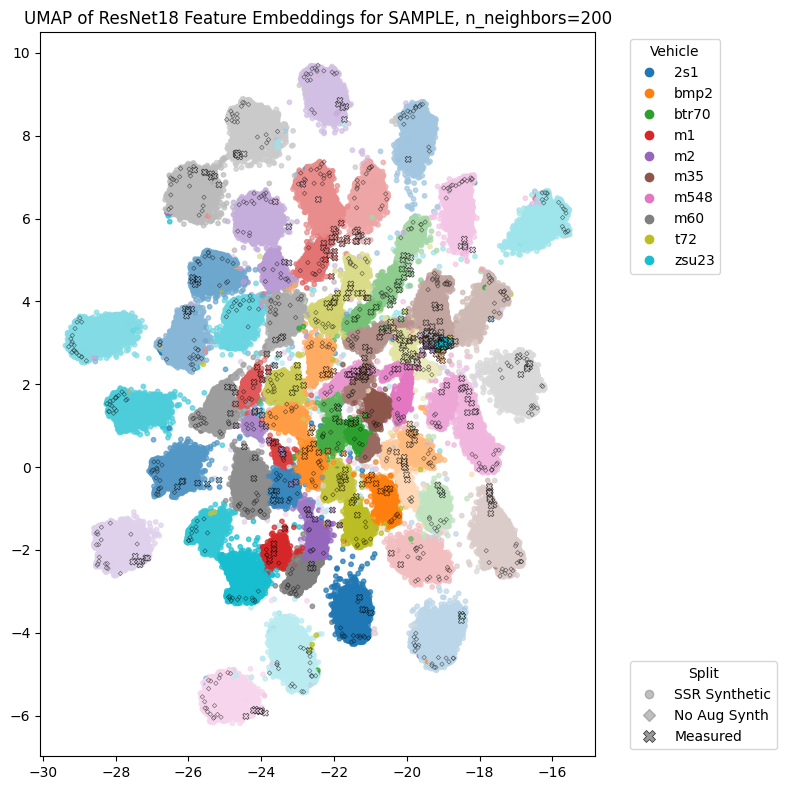

[2026-07-03 21:25:23.767] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 21:25:23.801] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-03 21:25:23.801] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


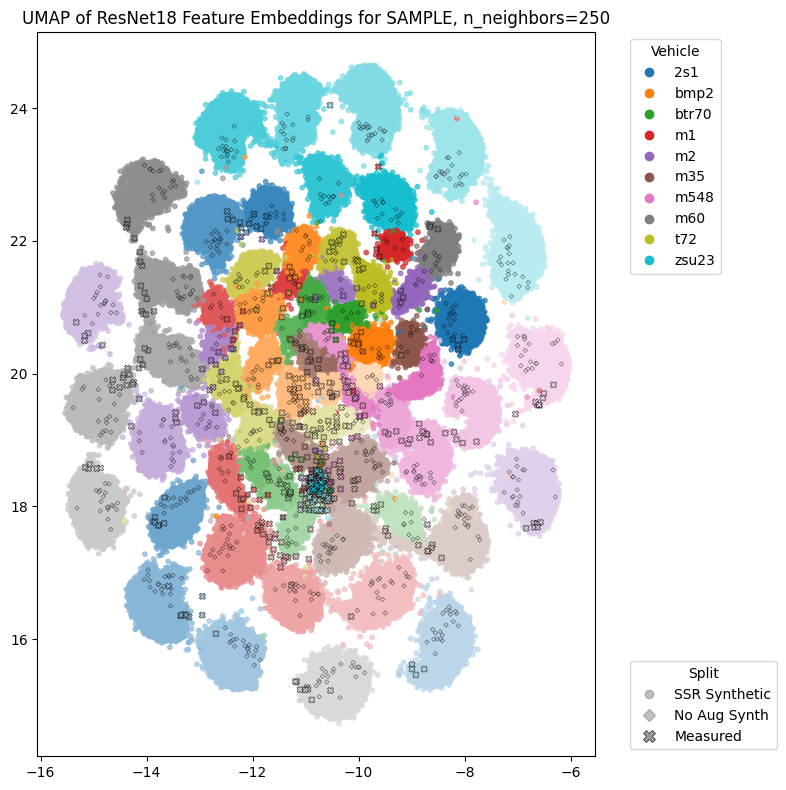

[2026-07-03 21:25:44.283] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-03 21:25:44.336] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-03 21:25:44.336] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


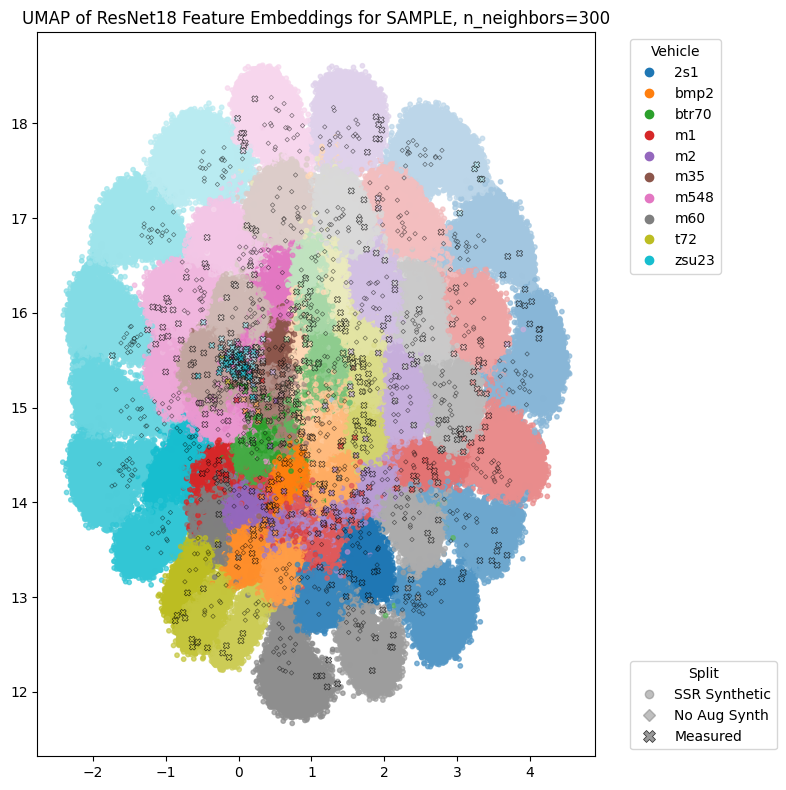

In [26]:
combined_feats = np.concatenate([SSR_synth_feats,  synth_feats, meas_feats],  axis=0)
combined_labels = np.concatenate([SSR_synth_labels,  synth_labels, meas_labels], axis=0)

pca = PCA(n_components = 50)
combined_feats_pca = pca.fit_transform(combined_feats)
print(f"Variance explained using {50} components: {pca.explained_variance_ratio_.sum():.3f}")

for num in [50, 100, 200, 250, 300]:

    reducer = UMAP(
            n_neighbors=num,
            min_dist=0.25,
            n_components=2,
            metric = "cosine"
        )

    features_2d_umap = reducer.fit_transform(combined_feats_pca)

    n_vehicles = len(new_SSR_synth_ds_14_15_16.dataset.classes)
    n_bins_per_vehicle = total_bins // n_vehicles 

    bin_colors = make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle)

    def labels_to_colors(label_array, bin_colors):
        return [bin_colors[l] for l in label_array]

    train_colors = labels_to_colors(combined_labels[:len(SSR_synth_feats)], bin_colors)
    synth_colors = labels_to_colors(combined_labels[len(SSR_synth_feats):len(SSR_synth_feats) + len(synth_feats)], bin_colors)
    test_colors  = labels_to_colors(combined_labels[len(SSR_synth_feats) + len(synth_feats):], bin_colors)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d_umap[:len(SSR_synth_feats), 0],
        features_2d_umap[:len(SSR_synth_feats), 1],
        c=train_colors,
        s=10,
        alpha=0.7,
        marker = "o"
    )

    plt.scatter(
        features_2d_umap[len(SSR_synth_feats) + len(synth_feats):, 0],
        features_2d_umap[len(SSR_synth_feats) + len(synth_feats):, 1],
        c=test_colors,
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k"
    )

    plt.scatter(
        features_2d_umap[len(SSR_synth_feats):len(SSR_synth_feats) + len(synth_feats), 0],
        features_2d_umap[len(SSR_synth_feats):len(SSR_synth_feats) + len(synth_feats), 1],
        c=synth_colors,
        s=5,
        alpha=0.5,
        linewidths=0.5,
        edgecolors="k",
        marker = "D"
    )

    tab10 = plt.colormaps["tab10"]
    vehicle_handles = [
        Line2D([0], [0], marker="o", color=tab10(v), linestyle="None",
            markersize=6, label=new_SSR_synth_ds_14_15_16.dataset.classes[v])
        for v in range(n_vehicles)
    ]
    class_legend = plt.legend(handles=vehicle_handles, title="Vehicle",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.add_artist(class_legend)

    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="SSR Synthetic"),
        Line2D([0], [0], marker="D", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synth"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"UMAP of ResNet18 Feature Embeddings for SAMPLE, n_neighbors={num}")
    plt.tight_layout()
    plt.show()

In [27]:
no_aug_synth_ds_14_15_16 = filter_by_elev(no_aug_synth_ds, {14, 15, 16})
s, b, total_bins, new_classes_train, new_to_old_classes_train = build_azimuth_bin_map(no_aug_synth_ds_14_15_16, bin_width=10)
new_no_aug_synth_ds_14_15_16 = AzimuthBinnedDataset(no_aug_synth_ds_14_15_16, s, new_classes_train)

meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes_test, new_to_old_classes_test = build_azimuth_bin_map(meas_ds_17, bin_width=10)
new_meas_ds_17 = AzimuthBinnedDataset(meas_ds_17, s, new_classes_test)


device = torch.device("cuda:0")
seed_lst = [10]
for i, seed in enumerate(seed_lst):
    set_seed(seed)
    model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(test_ds.classes))
    )
    # Load your trained weights
    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/SSR_w_noise_7times/rn18_seed{seed}_b16_ssr80.pth"),
        map_location=device
    ))

    # this gives the synth_features and synth_labels
    synth_features, synth_labels, _ = _get_features_and_preds_from_model(model, new_no_aug_synth_ds_14_15_16, device, seed)
    meas_features, meas_labels, meas_preds = _get_features_and_preds_from_model(model, new_meas_ds_17, device, seed)

    old_synth_labels = cp.array([new_to_old_classes_train[synth_labels[i].item()] for i in range(len(synth_labels))])
    old_meas_labels = cp.array([new_to_old_classes_test[meas_labels[i].item()] for i in range(len(meas_labels))])
    old_meas_preds = cp.array([new_to_old_classes_test[meas_preds[i].item()] for i in range(len(meas_preds))])

In [28]:
cosine_d_true_class, cosine_n_true_class = k_nearest_neighbors_by_true_class(
    meas_features, old_meas_labels, synth_features, old_synth_labels, metric = "cosine"
)

Class       q= 1  q= 3  q= 5
----------------------------
2s1         0.417  0.833  0.958  (n=48)
bmp2        0.673  0.846  1.000  (n=52)
btr70       0.571  0.796  0.878  (n=49)
m1          0.540  0.760  0.920  (n=50)
m2          0.708  0.896  0.958  (n=48)
m35         0.652  0.870  0.957  (n=46)
m548        0.652  0.870  0.957  (n=46)
m60         0.500  0.707  0.897  (n=58)
t72         0.654  0.885  0.942  (n=52)
zsu23       0.359  0.769  0.897  (n=39)
----------------------------
Overall     0.576  0.822  0.936  (n=488)
Class       q= 1  q= 3  q= 5
----------------------------
2s1         20.000  40.000  46.000  (n=48)
bmp2        35.000  44.000  52.000  (n=52)
btr70       28.000  39.000  43.000  (n=49)
m1          27.000  38.000  46.000  (n=50)
m2          34.000  43.000  46.000  (n=48)
m35         30.000  40.000  44.000  (n=46)
m548        30.000  40.000  44.000  (n=46)
m60         29.000  41.000  52.000  (n=58)
t72         34.000  46.000  49.000  (n=52)
zsu23       14.000  30.000 

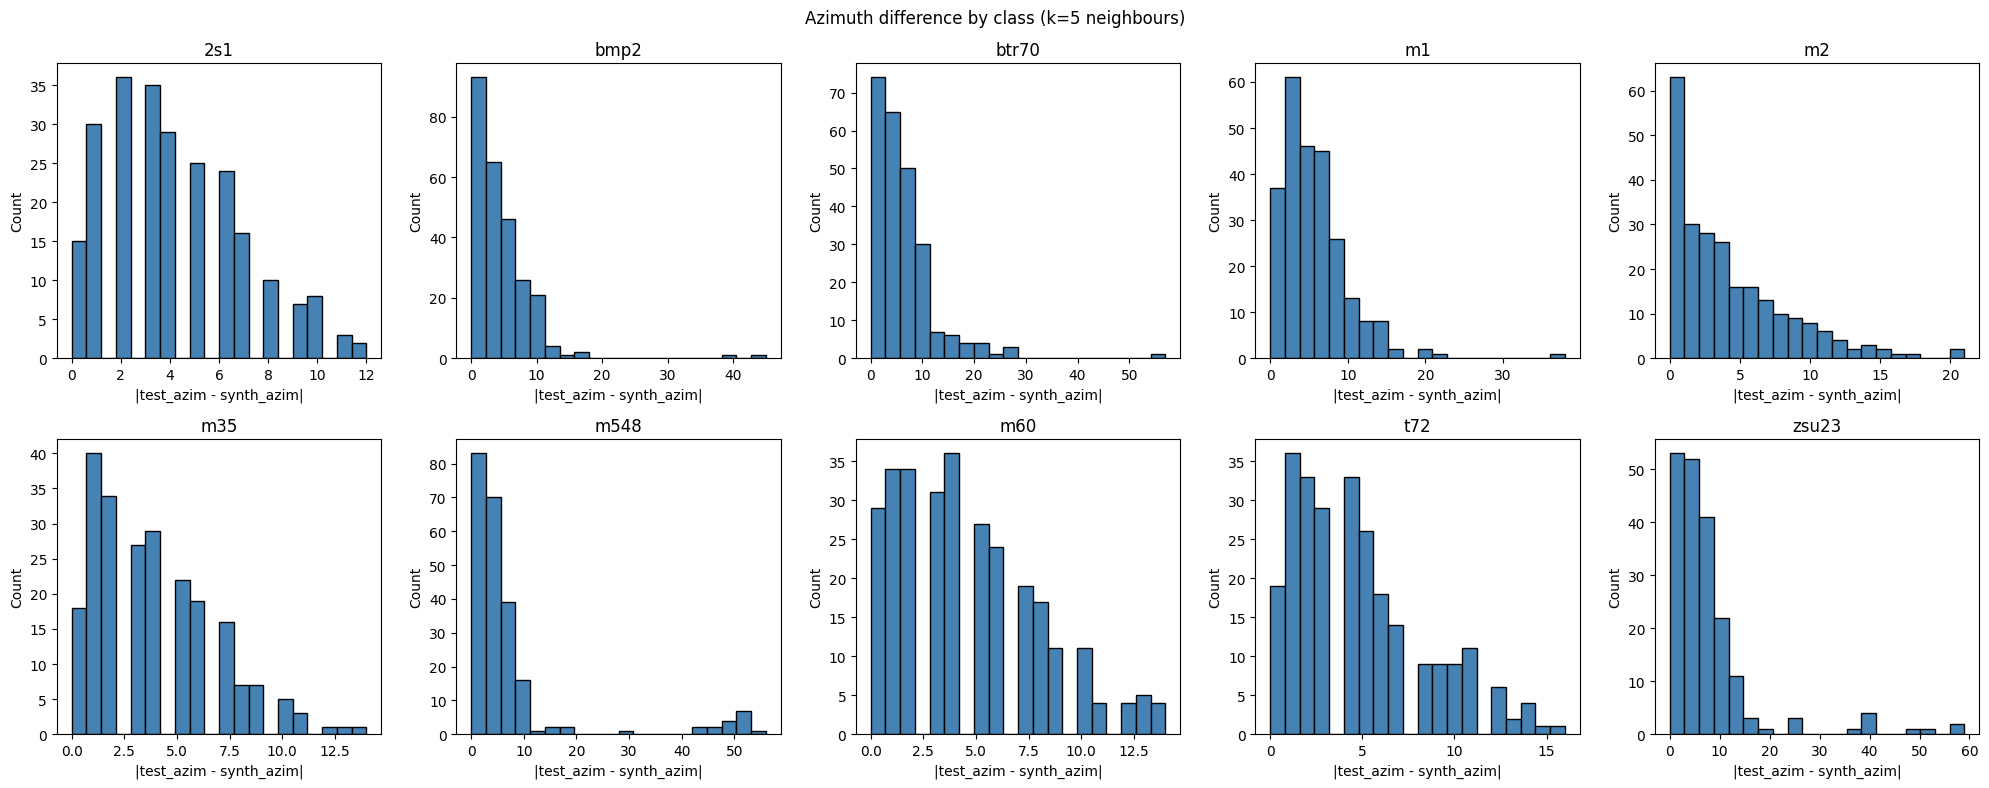

In [29]:
results, azim_diffs = azim_agreement_analysis_by_class(
    new_meas_ds_17.dataset, old_meas_labels, old_meas_preds,
    new_no_aug_synth_ds_14_15_16.dataset, cosine_n_true_class,
    q_values=[1, 3, 5],
    k = 5
)

results, azim_diffs = azim_agreement_analysis_by_class(
    new_meas_ds_17.dataset, old_meas_labels, old_meas_preds,
    new_no_aug_synth_ds_14_15_16.dataset, cosine_n_true_class,
    q_values=[1, 3, 5], k = 5, normalise = False
)

results, azim_diffs = cp.asnumpy(results), cp.asnumpy(azim_diffs)

correct_mask    = cp.asnumpy(old_meas_preds) == cp.asnumpy(old_meas_labels)
correct_classes = cp.asnumpy(old_meas_labels)[np.where(correct_mask)[0]]
plot_azim_diffs_by_class(new_meas_ds_17.dataset, azim_diffs, correct_classes)